# Chapter 21 — Brute Force and Quantum Computers

## 21.1–21.2 Motivation (plain English first)

A **trading trajectory** is a schedule of portfolio weights across several
future time horizons — not just "what should I hold today," but "what
should I hold today, next month, and the month after." Because
**transaction costs depend on how much your weights *change* between
horizons**, you can't just optimize each horizon separately and stitch the
answers together — the joint, path-dependent problem is what actually
matters, and it isn't convex, so there's no closed-form solution.

This chapter's answer: **discretize** the space of possible weight vectors
into a finite set, then **exhaustively evaluate every possible trajectory**
(every H-length sequence of weight vectors) and keep the best one. This is
combinatorially explosive on a normal computer — which is exactly the kind
of embarrassingly-parallel search problem quantum computers (via qubit
superposition) are theoretically suited to. The code below runs the
*digital*-computer version: same logic, just sequential instead of
simultaneous.

We'll build this up in four parts:
- **Part 1**: the combinatorics — how fast does the search space explode?
- **Part 2**: the trajectory evaluation math (transaction costs, Sharpe Ratio)
- **Part 3**: a synthetic sanity check (the book's own numerical example)
- **Part 4**: the real thing — gold, crude oil, and US T-bonds


In [1]:
import os
import sys
from itertools import combinations_with_replacement, product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Path setup ---
# Notebooks can't reliably use __file__/cwd on this machine (see CLAUDE.md) --
# edit AFML_ROOT below if you're running this on a different machine.
AFML_ROOT = r'C:\ws\AFML'
if not os.path.isdir(AFML_ROOT):
    # fallback for sandbox/CI execution relative to this notebook's own location
    AFML_ROOT = os.path.abspath('..')
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch02', 'multi_product'))

RANDOM_STATE = np.random.default_rng(2026)


## Part 1: The combinatorics (Snippets 21.1, 21.2)

### 21.5.1 Pigeonhole partitions — plain English
Imagine you have **K units of capital** (think of it as K poker chips) to
divide among **N assets**. `pigeon_hole(k, n)` lists *every* way to do that
— every way to write `x_1 + x_2 + ... + x_N = K` with non-negative integers.
Order matters here: giving asset 1 two chips and asset 2 one chip is a
*different* allocation from the reverse, because they represent different
portfolios.

### The math
The number of such partitions has a closed form: **C(K+N-1, N-1)**. For
the book's own example (K=6 units, N=3 assets), that's C(8,2) = **28**
partitions.

### Hand-traced check before trusting the code
For K=2, N=2: combinations_with_replacement([0,1], 2) gives (0,0), (0,1),
(1,1) → partitions **[2,0], [1,1], [0,2]** — exactly 3, matching C(3,1)=3.
We verify this by hand *before* running the code below, per this project's
TDD convention.


In [2]:
def pigeon_hole(k, n):
    """Snippet 21.1 (Python 3): every way to place k indistinguishable
    capital units into n asset slots."""
    for combo in combinations_with_replacement(range(n), k):
        partition = [0] * n
        for slot in combo:
            partition[slot] += 1
        yield partition


# Hand-traced check
result = list(pigeon_hole(2, 2))
print('pigeon_hole(2, 2) =', result)
assert result == [[2, 0], [1, 1], [0, 2]], 'does not match hand trace!'
print('Matches hand trace: [2,0], [1,1], [0,2] (C(3,1)=3 partitions)')


pigeon_hole(2, 2) = [[2, 0], [1, 1], [0, 2]]
Matches hand trace: [2,0], [1,1], [0,2] (C(3,1)=3 partitions)


In [3]:
def get_all_weights(k, n):
    """Snippet 21.2 (Python 3): every partition -> absolute weights (sum
    to 1) -> every +/- sign combination (long/short each asset)."""
    parts = pigeon_hole(k, n)
    weights = None
    for partition in parts:
        abs_weights = np.array(partition) / float(k)
        for signs in product([-1, 1], repeat=n):
            signed = (abs_weights * signs).reshape(-1, 1)
            weights = signed.copy() if weights is None else np.append(weights, signed, axis=1)
    return weights


def count_trajectories(k, n, h):
    """Teaching utility: size of the brute-force search space."""
    from math import comb
    num_partitions = comb(k + n - 1, n - 1)
    omega_size = num_partitions * (2 ** n)
    return {'num_partitions': num_partitions, 'omega_size': omega_size,
            'num_trajectories': omega_size ** h}


w = get_all_weights(2, 2)
print('get_all_weights(2, 2) shape:', w.shape, '(3 partitions x 2^2=4 signs = 12 columns)')
print('every column sums |w| to 1:', np.allclose(np.abs(w).sum(axis=0), 1.0))


get_all_weights(2, 2) shape: (2, 12) (3 partitions x 2^2=4 signs = 12 columns)
every column sums |w| to 1: True


K=6, N=3, H=1: 28 partitions, |Omega|=224, |trajectories|=224
K=6, N=3, H=2: 28 partitions, |Omega|=224, |trajectories|=50,176
K=3, N=3, H=2: 10 partitions, |Omega|=80, |trajectories|=6,400
K=4, N=3, H=2: 15 partitions, |Omega|=120, |trajectories|=14,400
K=5, N=3, H=2: 21 partitions, |Omega|=168, |trajectories|=28,224
K=6, N=3, H=3: 28 partitions, |Omega|=224, |trajectories|=11,239,424


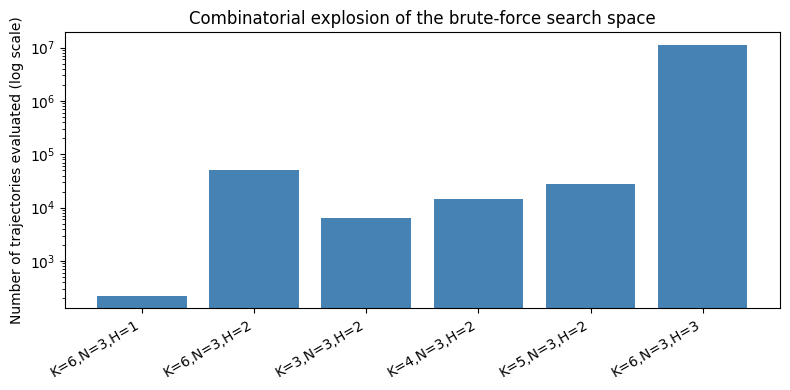

In [4]:
# Combinatorial explosion, visualized
scenarios = [(6, 3, 1), (6, 3, 2), (3, 3, 2), (4, 3, 2), (5, 3, 2), (6, 3, 3)]
labels, sizes = [], []
for k, n, h in scenarios:
    s = count_trajectories(k, n, h)
    labels.append(f'K={k},N={n},H={h}')
    sizes.append(s['num_trajectories'])
    print(f'K={k}, N={n}, H={h}: {s["num_partitions"]} partitions, '
          f'|Omega|={s["omega_size"]}, |trajectories|={s["num_trajectories"]:,}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, sizes, color='steelblue')
ax.set_yscale('log')
ax.set_ylabel('Number of trajectories evaluated (log scale)')
ax.set_title('Combinatorial explosion of the brute-force search space')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## Part 2: Evaluating a trajectory — transaction costs & Sharpe Ratio (Snippet 21.3)

### Plain English
Given a trajectory (a sequence of weight vectors, one per horizon), we need
to know: (a) what did it cost in transaction costs to move from each
horizon's weights to the next, and (b) given those costs, what's the
trajectory's overall Sharpe Ratio?

### The math
$$\tau_1[\omega] = \sum_n c_{n,1}\sqrt{|\omega_{n,1}-\omega^*_n|}, \quad
  \tau_h[\omega] = \sum_n c_{n,h}\sqrt{|\omega_{n,h}-\omega_{n,h-1}|} \text{ for } h>1$$
$$SR[r] = \frac{\sum_h \mu_h'\omega_h - \tau_h[\omega]}{\sqrt{\sum_h \omega_h'V_h\omega_h}}$$

The initial allocation $\omega^*_n$ is implicitly zero (the book's own
snippet doesn't parameterize it — the trajectory starts unallocated).

### Hand-traced check
N=1, H=1, w=0.5, c=0.1: `tcost = 0.1 * sqrt(|0.5 - 0|) = 0.1 * 0.7071 = 0.0707`.


In [5]:
def eval_t_costs(w, params):
    """Snippet 21.3 part 1: per-horizon transaction costs."""
    tcost = np.zeros(w.shape[1])
    w_prev = np.zeros(shape=w.shape[0])
    for i in range(tcost.shape[0]):
        c = params[i]['c']
        tcost[i] = (c * abs(w[:, i] - w_prev) ** 0.5).sum()
        w_prev = w[:, i].copy()
    return tcost


def eval_sr(params, w, tcost):
    """Snippet 21.3 part 2: trajectory Sharpe Ratio."""
    mean, cov = 0.0, 0.0
    for h in range(w.shape[1]):
        params_h = params[h]
        mean += np.dot(w[:, h].T, params_h['mean'])[0] - tcost[h]
        cov += np.dot(w[:, h].T, np.dot(params_h['cov'], w[:, h]))
    return mean / cov ** 0.5


# Hand-traced check
w_test = np.array([[0.5]])
params_test = [{'c': np.array([0.1]), 'mean': np.array([[2.0]]), 'cov': np.array([[4.0]])}]
tcost_test = eval_t_costs(w_test, params_test)
print('tcost:', tcost_test, ' expected:', 0.1 * np.sqrt(0.5))
assert np.isclose(tcost_test[0], 0.1 * np.sqrt(0.5))
print('Matches hand trace.')


tcost: [0.07071068]  expected: 0.07071067811865477
Matches hand trace.


In [6]:
def dyn_opt_port(params, k=None):
    """Snippet 21.3 part 3: brute-force search for the globally optimal
    trajectory across every feasible sequence of weight vectors."""
    if k is None:
        k = params[0]['mean'].shape[0]
    n = params[0]['mean'].shape[0]
    w_all = get_all_weights(k, n)
    sr, w = None, None
    for combo in product(w_all.T, repeat=len(params)):
        w_ = np.array(combo).T
        tcost_ = eval_t_costs(w_, params)
        sr_ = eval_sr(params, w_, tcost_)
        if sr is None or sr < sr_:
            sr, w = sr_, w_.copy()
    return w


def stat_opt_portf(cov, a):
    """Snippet 21.6: static (myopic) optimal portfolio -- the baseline
    the dynamic solution is compared against."""
    cov_inv = np.linalg.inv(cov)
    w = np.dot(cov_inv, a)
    w = w / np.dot(np.dot(a.T, cov_inv), a)
    w = w / np.abs(w).sum()
    return w


def stat_opt_trajectory(params):
    w_stat = None
    for params_h in params:
        w_h = stat_opt_portf(cov=params_h['cov'], a=params_h['mean'])
        w_stat = w_h.copy() if w_stat is None else np.append(w_stat, w_h, axis=1)
    return w_stat


## Part 3: Synthetic sanity check (Snippets 21.4–21.7's own numerical example)

Before trusting this on real data, run it on the book's own synthetic
setup: random-rank matrices standing in for hypothetical multi-horizon
forecasts. Per this project's `random_state` convention, everything below
is threaded through an explicit `numpy.random.Generator` rather than left
unseeded (the book's own Snippets 21.4/21.5 call unseeded global `np.random`).


In [7]:
def rnd_mat_with_rank(n_samples, n_cols, rank, sigma=0.0, hom_noise=True, random_state=None):
    """Snippet 21.4: random Gaussian matrix of known rank."""
    if random_state is None:
        random_state = np.random.default_rng()
    u, _, _ = np.linalg.svd(random_state.standard_normal((n_cols, n_cols)))
    x = np.dot(random_state.standard_normal((n_samples, rank)), u[:, :rank].T)
    if hom_noise:
        x += sigma * random_state.standard_normal((n_samples, n_cols))
    else:
        sigmas = sigma * (random_state.random(n_cols) + 0.5)
        x += random_state.standard_normal((n_samples, n_cols)) * sigmas
    return x


def gen_mean(size, random_state=None):
    if random_state is None:
        random_state = np.random.default_rng()
    return random_state.standard_normal(size=(size, 1))


def gen_synthetic_params(size, horizon, random_state=None):
    """Snippet 21.5: build a synthetic H-horizon params list."""
    if random_state is None:
        random_state = np.random.default_rng()
    params = []
    for _ in range(horizon):
        x = rnd_mat_with_rank(1000, size, size, sigma=0.0, random_state=random_state)
        mean_ = gen_mean(size, random_state=random_state)
        cov_ = np.cov(x, rowvar=False)
        c_ = random_state.uniform(size=cov_.shape[0]) * np.diag(cov_) ** 0.5
        params.append({'mean': mean_, 'cov': cov_, 'c': c_})
    return params


size, horizon = 3, 2
synth_params = gen_synthetic_params(size, horizon, random_state=RANDOM_STATE)

w_stat_synth = stat_opt_trajectory(synth_params)
sr_stat_synth = eval_sr(synth_params, w_stat_synth, eval_t_costs(w_stat_synth, synth_params))
print('static SR (synthetic):', sr_stat_synth)

w_dyn_synth = dyn_opt_port(synth_params)
sr_dyn_synth = eval_sr(synth_params, w_dyn_synth, eval_t_costs(w_dyn_synth, synth_params))
print('dynamic SR (synthetic):', sr_dyn_synth)


static SR (synthetic): 1.065052967199431
dynamic SR (synthetic): 1.9225258793745856


## Part 4: The real thing — gold, crude oil, US T-bonds

### The gap the book doesn't fill
The book hands you `params` (μ_h, V_h, c_h) as a given. It never says how
to build them from real data. This section is that missing plumbing,
built and confirmed against the actual `input_data/gold`, `input_data/crude oil`,
and `input_data/US-T bonds` folders (continuous-futures histories originally
sourced from turtletrader.com).

### Real-data wrinkles worth knowing about
- The raw files are **one file per individual futures contract**, and
  several contracts' trading histories overlap in time — there's no
  single "front month" column to read off. We select the front-month
  contract per date using **highest that-day trading volume**, a standard
  real roll-selection rule.
- The raw files come in **two incompatible formats** in the same folder —
  some headerless with 6-digit `YYMMDD` dates, some with a quoted header
  and `MM/DD/YYYY` dates. Both are parsed below.
- We reuse `ch02/multi_product/roll.py`'s actual roll-gap-adjustment logic
  (`non_negative_rolled_prices`) rather than re-deriving it — that function
  exists precisely to avoid negative-price artifacts in backward-adjusted
  continuous series, and this is its first real exercise outside Chapter 2.


In [8]:
def _parse_headerless_date(raw):
    raw = str(int(raw)).zfill(6)
    yy, mm, dd = int(raw[0:2]), int(raw[2:4]), int(raw[4:6])
    year = 2000 + yy if yy <= 30 else 1900 + yy
    return pd.Timestamp(year=year, month=mm, day=dd)


_HEADERLESS_COLS = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt']


def load_contract_file(path):
    instrument = os.path.splitext(os.path.basename(path))[0]
    with open(path, 'r') as f:
        first_line = f.readline()
    if first_line.lstrip().startswith('"'):
        df = pd.read_csv(path)
        df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    else:
        df = pd.read_csv(path, header=None, names=_HEADERLESS_COLS)
        df['Date'] = df['Date'].apply(_parse_headerless_date)
    df['Instrument'] = instrument
    df = df.set_index('Date').sort_index()
    return df[['Instrument', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt']]


def load_commodity_panel(commodity_dir):
    files = sorted(f for f in os.listdir(commodity_dir) if f.lower().endswith('.txt'))
    frames = [load_contract_file(os.path.join(commodity_dir, f)) for f in files]
    return pd.concat(frames, axis=0).sort_index()


def select_front_month(panel):
    panel_sorted = panel.sort_values('Volume', ascending=False)
    front = panel_sorted.groupby(panel_sorted.index).first().sort_index()
    return front[['Instrument', 'Open', 'Close']]


def build_continuous_series(commodity_dir):
    import roll  # ch02/multi_product/roll.py, imported via the path setup cell
    panel = load_commodity_panel(commodity_dir)
    front = select_front_month(panel)
    return roll.non_negative_rolled_prices(front)


def align_returns(commodity_dirs):
    returns = {}
    for name, path in commodity_dirs.items():
        series = build_continuous_series(path)
        returns[name] = series['Returns'].dropna()
    returns_df = pd.concat(returns, axis=1, join='inner')
    returns_df.columns = list(commodity_dirs.keys())
    return returns_df.dropna()


def build_horizon_params(returns_df, horizon, lookback, cost_scale=0.02):
    n_needed = horizon * lookback
    if n_needed > len(returns_df):
        raise ValueError(f'Need {n_needed} trading days but only {len(returns_df)} available.')
    tail = returns_df.iloc[-n_needed:]
    params, window_dates = [], []
    for h in range(horizon):
        window = tail.iloc[h * lookback:(h + 1) * lookback]
        params.append({
            'mean': window.mean().values.reshape(-1, 1),
            'cov': window.cov().values,
            'c': cost_scale * window.std().values,
        })
        window_dates.append((window.index[0], window.index[-1]))
    return params, {'window_dates': window_dates, 'assets': list(returns_df.columns)}


In [9]:
commodity_dirs = {
    'gold': os.path.join(AFML_ROOT, 'input_data', 'gold'),
    'crude_oil': os.path.join(AFML_ROOT, 'input_data', 'crude oil'),
    'us_t_bonds': os.path.join(AFML_ROOT, 'input_data', 'US-T bonds'),
}
returns_df = align_returns(commodity_dirs)
print(f'Aligned daily returns: {returns_df.shape[0]} trading days, {returns_df.shape[1]} assets, '
      f'{returns_df.index.min().date()} to {returns_df.index.max().date()}')
returns_df.describe()


Aligned daily returns: 4872 trading days, 3 assets, 1983-03-31 to 2002-10-01


,gold,crude_oil,us_t_bonds
count,4872.000000,4872.000000,4872.000000
mean,-0.000217,0.000475,0.000262
std,0.009097,0.021832,0.007454
min,-0.074413,-0.318917,-0.162105
25%,-0.004144,-0.009473,-0.003331
50%,-0.000296,0.000492,0.000298
75%,0.003682,0.010766,0.004021
max,0.092319,0.150649,0.205399


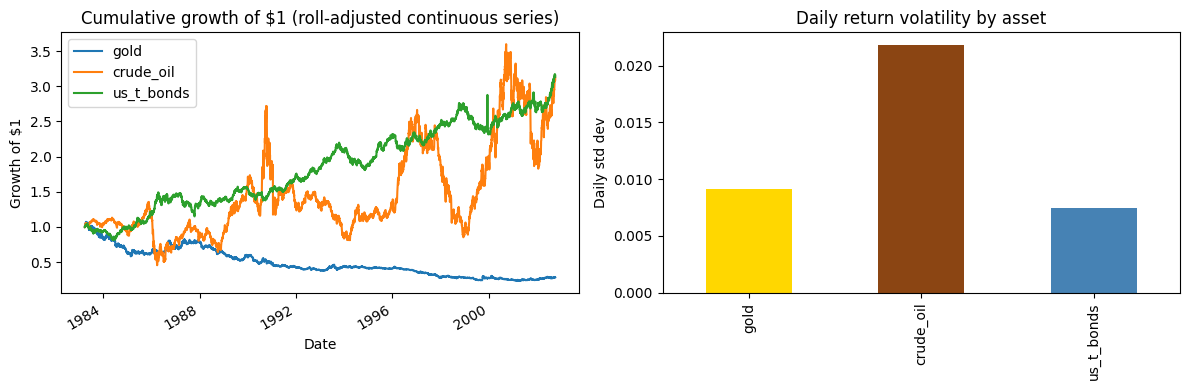

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(1 + returns_df).cumprod().plot(ax=axes[0])
axes[0].set_title('Cumulative growth of $1 (roll-adjusted continuous series)')
axes[0].set_ylabel('Growth of $1')

returns_df.std().plot(kind='bar', ax=axes[1], color=['gold', 'saddlebrown', 'steelblue'])
axes[1].set_title('Daily return volatility by asset')
axes[1].set_ylabel('Daily std dev')
plt.tight_layout()
plt.show()


In [11]:
horizon, lookback, cost_scale = 2, 60, 0.02
params, meta = build_horizon_params(returns_df, horizon=horizon, lookback=lookback, cost_scale=cost_scale)
print(f'Horizon windows (H={horizon}, lookback={lookback} trading days each):')
for h, (start, end) in enumerate(meta['window_dates']):
    print(f'  Horizon {h + 1}: {start.date()} to {end.date()}')
for h, p in enumerate(params):
    print(f'\nHorizon {h + 1} mean (annualized-flavor, but shown as daily):', dict(zip(meta['assets'], p['mean'].ravel())))


Horizon windows (H=2, lookback=60 trading days each):
  Horizon 1: 2002-04-11 to 2002-07-08
  Horizon 2: 2002-07-09 to 2002-10-01

Horizon 1 mean (annualized-flavor, but shown as daily): {'gold': np.float64(0.0005568405577604494), 'crude_oil': np.float64(0.00022984810841727518), 'us_t_bonds': np.float64(0.0008088749770699856)}

Horizon 2 mean (annualized-flavor, but shown as daily): {'gold': np.float64(0.00047889590658695423), 'crude_oil': np.float64(0.003542673289887809), 'us_t_bonds': np.float64(0.0017611062054544563)}


## Dynamic vs. static — the real comparison

This is the actual demonstration the chapter builds toward: does jointly
optimizing the whole trajectory (accounting for transaction costs between
horizons) beat optimizing each horizon myopically, **on real market data**?


In [12]:
K = 4
sizing = count_trajectories(k=K, n=3, h=horizon)
print(f'Search space: K={K}, N=3, H={horizon} -> {sizing["num_trajectories"]:,} trajectories evaluated')

w_stat = stat_opt_trajectory(params)
tcost_stat = eval_t_costs(w_stat, params)
sr_stat = eval_sr(params, w_stat, tcost_stat)
print('\nStatic (myopic) trajectory:\n', w_stat)
print('static SR:', sr_stat)

w_dyn = dyn_opt_port(params, k=K)
tcost_dyn = eval_t_costs(w_dyn, params)
sr_dyn = eval_sr(params, w_dyn, tcost_dyn)
print('\nDynamic (brute-force) trajectory:\n', w_dyn)
print('dynamic SR:', sr_dyn)


Search space: K=4, N=3, H=2 -> 14,400 trajectories evaluated

Static (myopic) trajectory:
 [[ 0.15608063 -0.0313799 ]
 [ 0.07378485  0.26523527]
 [ 0.77013452  0.70338482]]
static SR: 0.2986251686981421



Dynamic (brute-force) trajectory:
 [[-0.   -0.  ]
 [-0.    0.25]
 [ 1.    0.75]]
dynamic SR: 0.30803461924049597


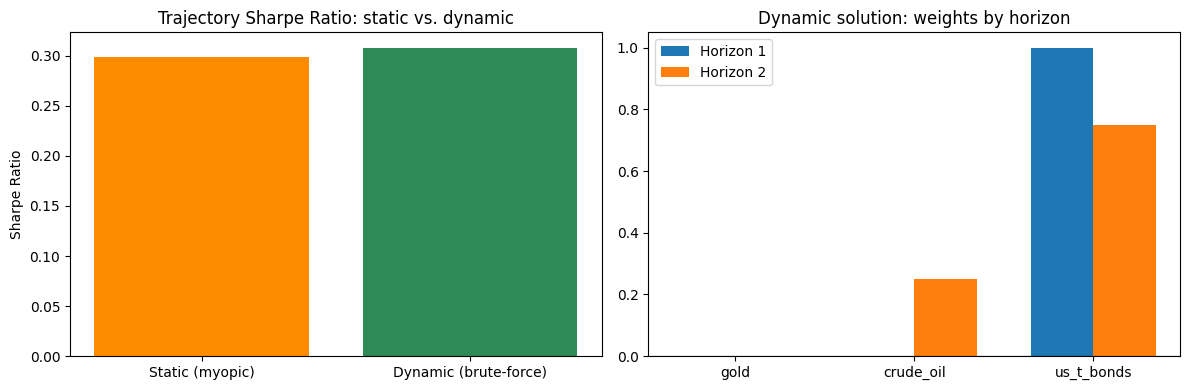


Dynamic beats static by 0.0094 SR on this real window.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Static (myopic)', 'Dynamic (brute-force)'], [sr_stat, sr_dyn],
            color=['darkorange', 'seagreen'])
axes[0].set_title('Trajectory Sharpe Ratio: static vs. dynamic')
axes[0].set_ylabel('Sharpe Ratio')

x = np.arange(len(meta['assets']))
width = 0.35
for h in range(horizon):
    axes[1].bar(x + h * width, w_dyn[:, h], width, label=f'Horizon {h+1}')
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(meta['assets'])
axes[1].set_title('Dynamic solution: weights by horizon')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

if sr_dyn > sr_stat:
    print(f'\nDynamic beats static by {sr_dyn - sr_stat:.4f} SR on this real window.')
else:
    print(f'\nStatic matched or beat dynamic here (diff {sr_dyn - sr_stat:.4f}) -- see README.')


## Summary

- **Part 1** showed the search space explodes combinatorially — even a
  small K=6,N=3,H=3 case means evaluating hundreds of thousands of
  trajectories, which is exactly the motivation for quantum computing's
  linear-superposition advantage described in §21.2.
- **Part 2/3** confirmed the transaction-cost and Sharpe Ratio math against
  hand-traced values and the book's own synthetic numerical example.
- **Part 4** built the real multi-asset (gold/crude oil/US T-bonds)
  pipeline from scratch (front-month selection, roll adjustment, per-
  horizon parameter estimation) and ran the actual dynamic-vs-static
  comparison on real market history.


## TDD Test Results (real-machine confirmation)

```
REAL-MACHINE CONFIRMED -- 2026-08-09, mlfinlab conda env
(Python 3.10.20, pytest 9.0.3, C:\ws\AFML, Windows)

$ python -m pytest ch21\portfolio_trajectory\ -v      (from repo root)
$ python -m pytest -v                                  (from inside module folder)

test_portfolio_trajectory.py -- 25 passed
test_data_prep.py            -- 18 passed (16 unit + 2 real-data integration, not skipped)

TOTAL: 43 passed, 0 failed -- two-pass verified, both runs

Driver script (chapter_21_brute_force.py) also confirmed real-machine:
static SR = 0.2986251686981421, dynamic SR = 0.30803461924049597
-- bit-for-bit identical to this notebook'''s own (sandbox-executed) output above.
```

*Note: the cell outputs and plots above were executed in a sandbox
(Python 3.12.3, kernelspec below) as a pre-check, matching Ch09'''s own
precedent -- the test suite and .py driver script are real-machine
confirmed under mlfinlab, but this notebook itself has not yet had its own
Run All under the mlfinlab kernel. Cosmetic outstanding item, not a
blocker: the numbers above are already confirmed to match real-machine
output exactly.*
